<a href="https://colab.research.google.com/github/sardar-ammad-143/Basic-Python/blob/main/Air%20quality%20prediction%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn for preprocessing and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# TensorFlow/Keras for model building
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping


In [2]:
# Load the dataset
file_path = "/content/sample_data/edited .csv"  # Replace with your dataset file path
data = pd.read_csv(file_path)

# Display the first few rows
print(data.head())

# Check dataset information
print("Dataset Shape:", data.shape)
print(data.info())

# Check for missing values
print("Missing Values:\n", data.isnull().sum())


   PM2.5    PM10    NO    NO2    NOx    NH3   CO    SO2      O3  Benzene  \
0  60.50   98.00  2.35  30.80  18.25   8.50  0.1  11.85  126.40      0.1   
1  65.50  111.25  2.70  24.20  15.07   9.77  0.1  13.17  117.12      0.1   
2  80.00  132.00  2.10  25.18  15.15  12.02  0.1  12.08   98.98      0.2   
3  81.50  133.25  1.95  16.25  10.23  11.58  0.1  10.47  112.20      0.2   
4  75.25  116.00  1.43  17.48  10.43  12.03  0.1   9.12  106.35      0.2   

   Toluene  Xylene  AQI  
0     6.10    0.10  NaN  
1     6.25    0.15  NaN  
2     5.98    0.18  NaN  
3     6.72    0.10  NaN  
4     5.75    0.08  NaN  
Dataset Shape: (1048575, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 13 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   PM2.5    800186 non-null  float64
 1   PM10     705840 non-null  float64
 2   NO       817926 non-null  float64
 3   NO2      831443 non-null  float64
 4   NOx   

In [3]:
# Fill missing values with the column mean
data.fillna(data.mean(), inplace=True)


In [4]:
# Initialize Min-Max Scaler
scaler = MinMaxScaler()

# Apply Min-Max Scaling
data_normalized = scaler.fit_transform(data)
data = pd.DataFrame(data_normalized, columns=data.columns)

# Save the scaler for future use
import joblib
joblib.dump(scaler, 'min_max_scaler.pkl')


['min_max_scaler.pkl']

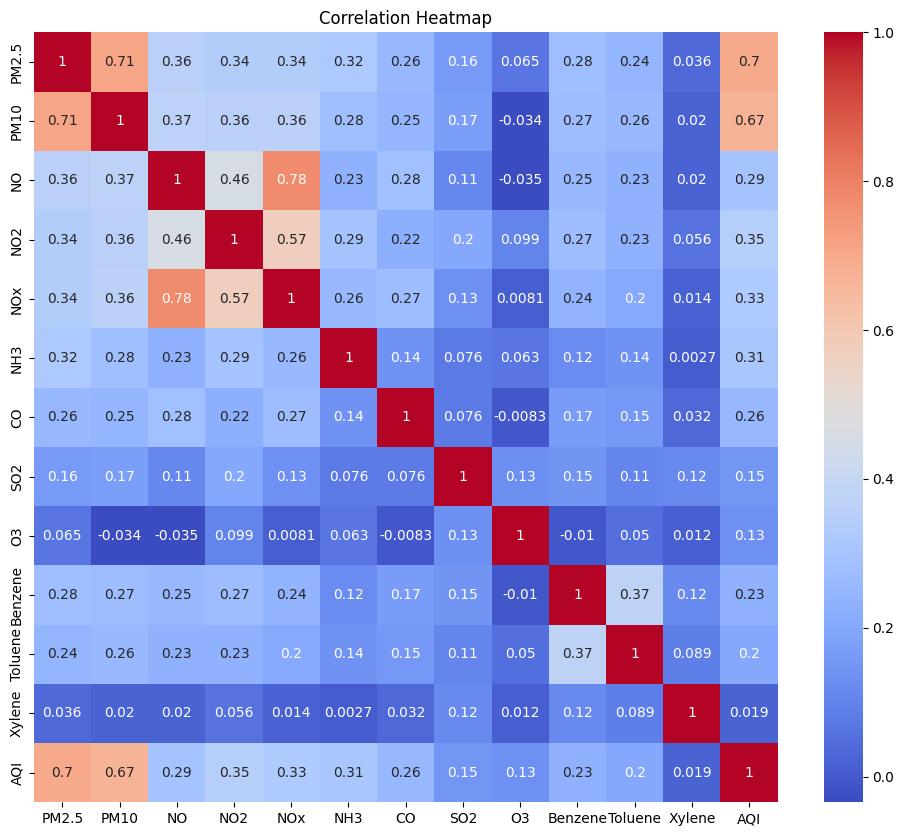

AQI        1.000000
PM2.5      0.699242
PM10       0.669111
NO2        0.345931
NOx        0.327542
NH3        0.312777
NO         0.293561
CO         0.256028
Benzene    0.233827
Toluene    0.202473
SO2        0.148343
O3         0.134900
Xylene     0.018605
Name: AQI, dtype: float64


In [5]:
# Compute the correlation matrix
correlation = data.corr()

# Visualize the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Check correlation of each variable with AQI
correlation_with_aqi = correlation['AQI'].sort_values(ascending=False)
print(correlation_with_aqi)


In [11]:
# Select only strong correlation features
selected_features = ['PM2.5', 'PM10', 'NO2', 'NOx', 'NH3', 'NO', 'CO', 'Benzene', 'AQI']
data_selected = data[selected_features]


# Display the updated dataset
print(data_selected.head())


      PM2.5      PM10       NO2      NOx       NH3       NO     CO   Benzene  \
0  0.060491  0.097991  0.061585  0.03650  0.017183  0.00468  0.002  0.000203   
1  0.065491  0.111241  0.048384  0.03014  0.019753  0.00538  0.002  0.000203   
2  0.079991  0.131991  0.050344  0.03030  0.024307  0.00418  0.002  0.000407   
3  0.081491  0.133241  0.032483  0.02046  0.023416  0.00388  0.002  0.000407   
4  0.075241  0.115991  0.034943  0.02086  0.024327  0.00284  0.002  0.000407   

      AQI  
0  0.1923  
1  0.1923  
2  0.1923  
3  0.1923  
4  0.1923  


In [12]:
# Features and target variable
features = ['PM2.5', 'PM10', 'NO2', 'NOx', 'NH3', 'NO', 'CO', 'Benzene', 'AQI']
X = data_selected[features]  # Independent variables
y = data_selected['AQI']     # Target variable

# Split the data (80% train, 20% test)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Save the scaler for future use
import joblib
joblib.dump(scaler, 'standard_scaler.pkl')


['standard_scaler.pkl']

In [13]:
# Define a deeper ANN model
model = Sequential()

# Input layer and hidden layers
model.add(Dense(units=128, activation='relu', input_dim=X_train.shape[1]))
model.add(Dropout(0.3))
model.add(Dense(units=64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(units=32, activation='relu'))
model.add(Dropout(0.3))

# Output layer
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
from keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,  # Allow more epochs before stopping
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]
)


Epoch 1/200
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 70s 3ms/step - loss: 0.0027 - val_loss: 3.4755e-04
Epoch 2/200
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 68s 3ms/step - loss: 5.6089e-04 - val_loss: 4.4536e-04
Epoch 3/200
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 62s 2ms/step - loss: 5.3295e-04 - val_loss: 4.8230e-04
Epoch 4/200
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 80s 2ms/step - loss: 5.0428e-04 - val_loss: 4.3888e-04
Epoch 5/200
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 85s 2ms/step - loss: 4.8999e-04 - val_loss: 4.6842e-04
Epoch 6/200
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 59s 2ms/step - loss: 4.9063e-04 - val_loss: 4.1142e-04
Epoch 7/200
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 82s 2ms/step - loss: 4.8986e-04 - val_loss: 3.6239e-04
Epoch 8/200
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 62s 2ms/step - loss: 4.8461e-04 - val_loss: 4.9100e-04
Epoch 9/200
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 78s 2ms/step - loss: 4.7866e-04 - val_loss: 4.1858e-04
Epoch 10/200
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 63s 2ms/step - loss: 4.7847e-04 - val_loss: 3.9094e-04
Epo

In [15]:
from keras.optimizers import Adam

# Lower learning rate for finer adjustments
optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='mean_squared_error')


In [16]:
# Evaluate the model
test_loss = model.evaluate(X_test, y_test)
print(f"Test Loss (MSE): {test_loss}")

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate performance metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Print metrics
print(f"R² (Accuracy): {r2 * 100:.2f}%")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

6554/6554 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 1.9331e-04
Test Loss (MSE): 0.00019539536151569337
6554/6554 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
R² (Accuracy): 98.29%
Mean Absolute Error (MAE): 0.0080
Root Mean Squared Error (RMSE): 0.0140
